In [2]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Unzip dataset
import zipfile
import os

print("Unzipping...")
with zipfile.ZipFile('/content/drive/MyDrive/EuroSAT_Dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')
print("Done!", os.listdir('/content/dataset'))

Mounted at /content/drive
Unzipping...
Done! ['train.csv', 'EuroSAT', 'validation.csv', 'EuroSATallBands_test_flat', 'EuroSATallBands', 'EuroSAT_test_flat']


In [3]:
import shutil

# Copy label_map.json from Drive to dataset folder
shutil.copy(
    '/content/drive/MyDrive/label_map.json',
    '/content/dataset/label_map.json'
)

# Now read and check it
import json
with open('/content/dataset/label_map.json', 'r') as f:
    label_map = json.load(f)

print(label_map)

{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


In [4]:
# Install rasterio for reading .tif files
!pip install rasterio -q

import rasterio
import numpy as np
import os

# Test reading one multispectral image
test_path = '/content/dataset/EuroSATallBands/train/AnnualCrop'
test_file = os.listdir(test_path)[0]

with rasterio.open(f'{test_path}/{test_file}') as src:
    data = src.read()  # reads all 13 bands → shape: [13, 64, 64]
    print(f"File: {test_file}")
    print(f"Shape: {data.shape}")
    print(f"Number of bands: {src.count}")
    print(f"Data type: {data.dtype}")
    print(f"\nPer band stats:")
    for i in range(13):
        print(f"  Band {i+1}: min={data[i].min():.1f}, max={data[i].max():.1f}, mean={data[i].mean():.1f}")

File: AnnualCrop_2206.tif
Shape: (13, 64, 64)
Number of bands: 13
Data type: uint16

Per band stats:
  Band 1: min=1344.0, max=1728.0, mean=1506.2
  Band 2: min=1004.0, max=1780.0, mean=1383.9
  Band 3: min=966.0, max=1945.0, mean=1444.3
  Band 4: min=792.0, max=2361.0, mean=1700.7
  Band 5: min=1413.0, max=2474.0, mean=1926.6
  Band 6: min=1881.0, max=2748.0, mean=2354.8
  Band 7: min=2137.0, max=3100.0, mean=2622.4
  Band 8: min=2047.0, max=3623.0, mean=2566.5
  Band 9: min=717.0, max=930.0, mean=872.3
  Band 10: min=11.0, max=16.0, mean=14.2
  Band 11: min=2694.0, max=3793.0, mean=3315.6
  Band 12: min=1405.0, max=3136.0, mean=2407.7
  Band 13: min=2365.0, max=3365.0, mean=2872.1


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os
import rasterio
from torch.utils.data import Dataset, DataLoader
from torchvision import models

# ============================================
# Custom Dataset for 13-band .tif files
# ============================================
class EuroSATMultispectral(Dataset):
    def __init__(self, root_dir, split='train'):
        self.root_dir = root_dir
        self.split = split
        self.samples = []
        self.class_names = sorted(os.listdir(os.path.join(root_dir, split)))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.class_names)}

        # Collect all file paths and labels
        for cls in self.class_names:
            cls_folder = os.path.join(root_dir, split, cls)
            for fname in os.listdir(cls_folder):
                if fname.endswith('.tif'):
                    self.samples.append((
                        os.path.join(cls_folder, fname),
                        self.class_to_idx[cls]
                    ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        # Read all 13 bands
        with rasterio.open(path) as src:
            data = src.read().astype(np.float32)  # shape: [13, 64, 64]

        # Normalize each band to 0-1 range
        # Sentinel-2 max reflectance value is 10000
        data = data / 10000.0
        data = np.clip(data, 0, 1)  # clip any outliers

        # Convert to tensor
        tensor = torch.FloatTensor(data)

        return tensor, label

# ============================================
# Create datasets and dataloaders
# ============================================
ms_root = '/content/dataset/EuroSATallBands'

train_dataset = EuroSATMultispectral(ms_root, split='train')
val_dataset = EuroSATMultispectral(ms_root, split='val')

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print("✅ Multispectral dataset loaded!")
print(f"Classes: {train_dataset.class_names}")
print(f"Train images: {len(train_dataset)}")
print(f"Val images: {len(val_dataset)}")

# Check one batch
images, labels = next(iter(train_loader))
print(f"\nBatch shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Value range: min={images.min():.3f}, max={images.max():.3f}")

✅ Multispectral dataset loaded!
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Train images: 18900
Val images: 4050

Batch shape: torch.Size([32, 13, 64, 64])
Labels shape: torch.Size([32])
Value range: min=0.000, max=0.755


In [9]:
# ============================================
# Multispectral Model — Modified EfficientNet
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load EfficientNet-B0
model_ms = models.efficientnet_b0(weights='IMAGENET1K_V1')

# ============================================
# KEY DIFFERENCE — modify first layer for 13 channels
# ============================================
# Original first conv layer expects 3 channels (RGB)
# We need to change it to accept 13 channels

original_conv = model_ms.features[0][0]  # original 3-channel conv layer

# Create new conv layer with 13 input channels
new_conv = nn.Conv2d(
    in_channels=13,        # 13 bands instead of 3
    out_channels=original_conv.out_channels,
    kernel_size=original_conv.kernel_size,
    stride=original_conv.stride,
    padding=original_conv.padding,
    bias=False
)

# Smart weight initialization:
# Copy RGB weights and average them across 13 channels
# This is better than random initialization
with torch.no_grad():
    # Average the 3 RGB channel weights
    rgb_weights = original_conv.weight.mean(dim=1, keepdim=True)
    # Repeat for all 13 channels
    new_conv.weight = nn.Parameter(rgb_weights.repeat(1, 13, 1, 1))

# Replace the first conv layer
model_ms.features[0][0] = new_conv

# Replace final layer for 10 classes
num_features = model_ms.classifier[1].in_features
model_ms.classifier[1] = nn.Linear(num_features, 10)

model_ms = model_ms.to(device)

print(f"✅ Multispectral model ready on {device}")
print(f"First conv layer: {model_ms.features[0][0]}")
print(f"Final layer: {model_ms.classifier[1]}")
print(f"Total parameters: {sum(p.numel() for p in model_ms.parameters()):,}")

✅ Multispectral model ready on cuda
First conv layer: Conv2d(13, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
Final layer: Linear(in_features=1280, out_features=10, bias=True)
Total parameters: 4,023,238


✅ Model loaded!
Calculating baseline accuracy...
Baseline accuracy (all 13 bands): 98.44%

Ablating each band...
  B1 (Coastal Aerosol): accuracy=95.19% (drop=3.26%)
  B2 (Blue): accuracy=86.91% (drop=11.53%)
  B3 (Green): accuracy=93.68% (drop=4.77%)
  B4 (Red): accuracy=95.63% (drop=2.81%)
  B5 (Red Edge 1): accuracy=95.51% (drop=2.94%)
  B6 (Red Edge 2): accuracy=95.33% (drop=3.11%)
  B7 (Red Edge 3): accuracy=89.33% (drop=9.11%)
  B8 (NIR): accuracy=69.36% (drop=29.09%)
  B8A (Narrow NIR): accuracy=93.16% (drop=5.28%)
  B9 (Water Vapor): accuracy=98.37% (drop=0.07%)
  B10 (Cirrus): accuracy=82.35% (drop=16.10%)
  B11 (SWIR 1): accuracy=94.86% (drop=3.58%)
  B12 (SWIR 2): accuracy=96.91% (drop=1.53%)


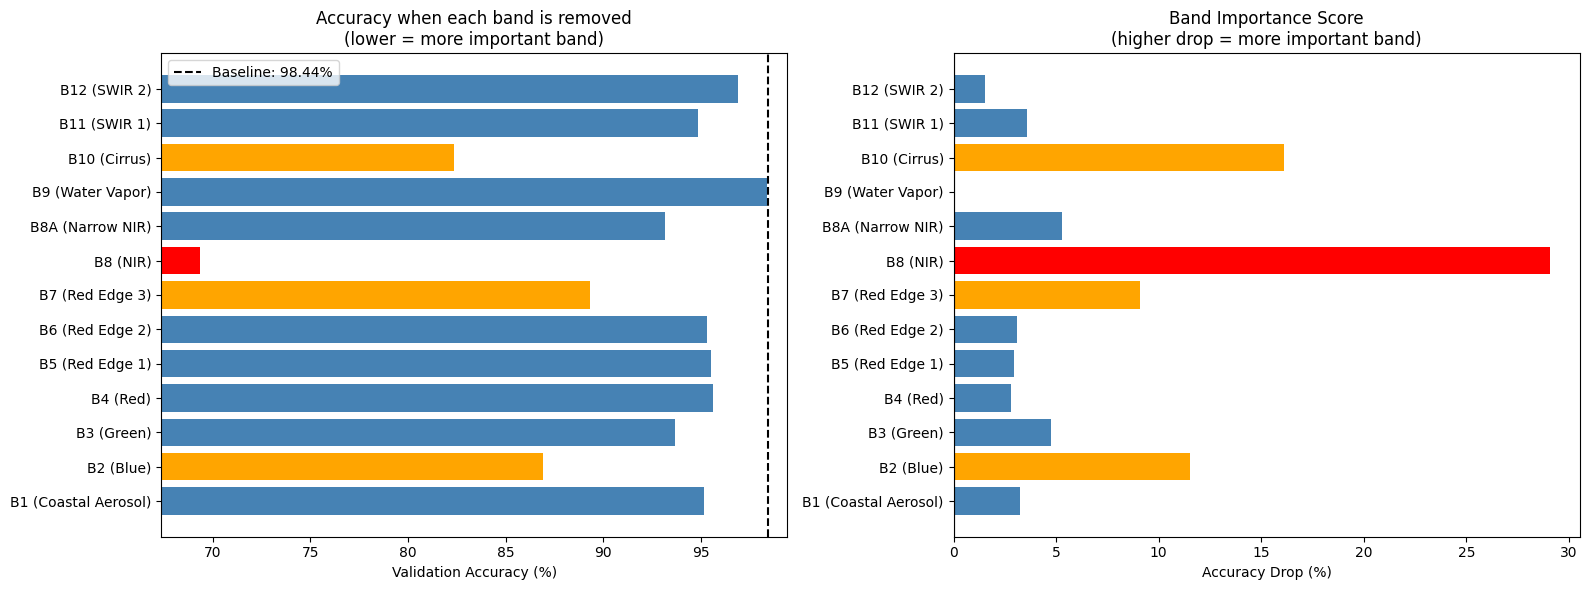


=== Band Importance Ranking ===
  #1 B8 (NIR): 29.09% drop
  #2 B10 (Cirrus): 16.10% drop
  #3 B2 (Blue): 11.53% drop
  #4 B7 (Red Edge 3): 9.11% drop
  #5 B8A (Narrow NIR): 5.28% drop
  #6 B3 (Green): 4.77% drop
  #7 B11 (SWIR 1): 3.58% drop
  #8 B1 (Coastal Aerosol): 3.26% drop
  #9 B6 (Red Edge 2): 3.11% drop
  #10 B5 (Red Edge 1): 2.94% drop
  #11 B4 (Red): 2.81% drop
  #12 B12 (SWIR 2): 1.53% drop
  #13 B9 (Water Vapor): 0.07% drop


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import models

# ============================================
# Band Importance via Ablation Study
# ============================================
# Idea: remove one band at a time (set it to 0)
# and measure how much accuracy drops
# The band that causes the BIGGEST drop = most important

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load multispectral model
model_ms = models.efficientnet_b0(weights=None)
original_conv = model_ms.features[0][0]
new_conv = nn.Conv2d(13, original_conv.out_channels,
                     kernel_size=original_conv.kernel_size,
                     stride=original_conv.stride,
                     padding=original_conv.padding,
                     bias=False)
model_ms.features[0][0] = new_conv
model_ms.classifier[1] = nn.Linear(model_ms.classifier[1].in_features, 10)
model_ms.load_state_dict(torch.load('/content/drive/MyDrive/best_efficientnet_ms.pth'))
model_ms = model_ms.to(device)
model_ms.eval()

print("✅ Model loaded!")

# ============================================
# First get baseline accuracy (all 13 bands)
# ============================================
def get_accuracy(loader, model, device, ablate_band=None):
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            # If ablating a band, set it to 0
            if ablate_band is not None:
                images = images.clone()
                images[:, ablate_band, :, :] = 0

            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return 100. * correct / total

# Baseline accuracy with all bands
print("Calculating baseline accuracy...")
baseline_acc = get_accuracy(val_loader, model_ms, device, ablate_band=None)
print(f"Baseline accuracy (all 13 bands): {baseline_acc:.2f}%")

# ============================================
# Ablate each band one at a time
# ============================================
band_names = [
    'B1 (Coastal Aerosol)',
    'B2 (Blue)',
    'B3 (Green)',
    'B4 (Red)',
    'B5 (Red Edge 1)',
    'B6 (Red Edge 2)',
    'B7 (Red Edge 3)',
    'B8 (NIR)',
    'B8A (Narrow NIR)',
    'B9 (Water Vapor)',
    'B10 (Cirrus)',
    'B11 (SWIR 1)',
    'B12 (SWIR 2)'
]

print("\nAblating each band...")
accuracies = []
importance_scores = []

for band_idx in range(13):
    acc = get_accuracy(val_loader, model_ms, device, ablate_band=band_idx)
    drop = baseline_acc - acc
    accuracies.append(acc)
    importance_scores.append(drop)
    print(f"  {band_names[band_idx]}: accuracy={acc:.2f}% (drop={drop:.2f}%)")

# ============================================
# Plot band importance
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — accuracy when band is removed
colors = ['red' if s == max(importance_scores) else
          'orange' if s > np.mean(importance_scores) else
          'steelblue' for s in importance_scores]

axes[0].barh(band_names, accuracies, color=colors)
axes[0].axvline(x=baseline_acc, color='black', linestyle='--', label=f'Baseline: {baseline_acc:.2f}%')
axes[0].set_xlabel('Validation Accuracy (%)')
axes[0].set_title('Accuracy when each band is removed\n(lower = more important band)')
axes[0].legend()
axes[0].set_xlim([min(accuracies)-2, baseline_acc+1])

# Plot 2 — importance score (accuracy drop)
axes[1].barh(band_names, importance_scores, color=colors)
axes[1].set_xlabel('Accuracy Drop (%)')
axes[1].set_title('Band Importance Score\n(higher drop = more important band)')
axes[1].axvline(x=0, color='black', linestyle='-')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/band_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print ranking
print("\n=== Band Importance Ranking ===")
ranked = sorted(zip(importance_scores, band_names), reverse=True)
for rank, (score, name) in enumerate(ranked, 1):
    print(f"  #{rank} {name}: {score:.2f}% drop")

Computing NDVI and NDWI per class...
  AnnualCrop: NDVI=0.389, NDWI=-0.402
  Forest: NDVI=0.708, NDWI=-0.567
  HerbaceousVegetation: NDVI=0.363, NDWI=-0.348
  Highway: NDVI=0.474, NDWI=-0.412
  Industrial: NDVI=0.230, NDWI=-0.210
  Pasture: NDVI=0.665, NDWI=-0.547
  PermanentCrop: NDVI=0.354, NDWI=-0.377
  Residential: NDVI=0.330, NDWI=-0.305
  River: NDVI=0.310, NDWI=-0.192
  SeaLake: NDVI=-0.246, NDWI=0.443


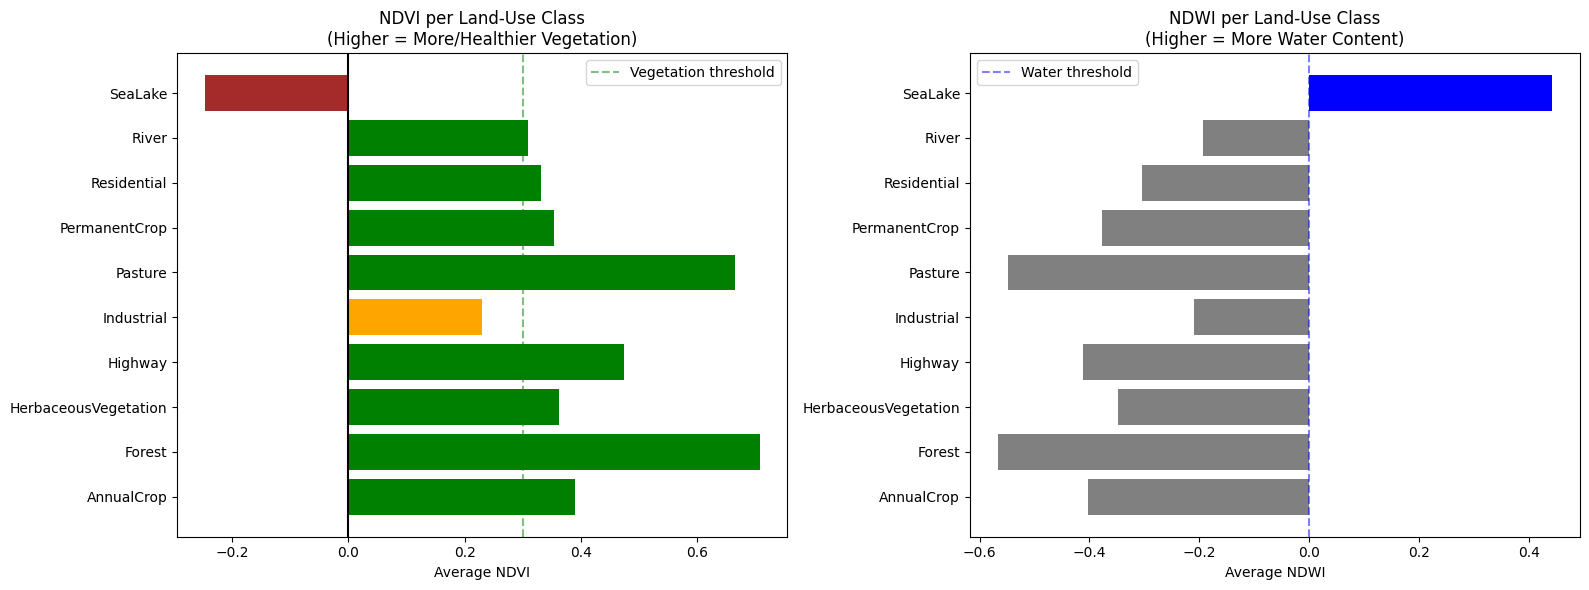

✅ NDVI/NDWI analysis saved!


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import os

# ============================================
# What are NDVI and NDWI?
# ============================================
# NDVI = (NIR - Red) / (NIR + Red)
# Values: -1 to +1
# High NDVI (0.6-1.0) = dense healthy vegetation
# Low NDVI (0-0.3)    = bare soil or urban
# Negative NDVI       = water

# NDWI = (Green - NIR) / (Green + NIR)
# Values: -1 to +1
# High NDWI (positive) = water present
# Low NDWI (negative)  = no water, dry land

# ============================================
# In EuroSATallBands, band order is:
# Band 0 = B1, Band 1 = B2(Blue), Band 2 = B3(Green)
# Band 3 = B4(Red), Band 7 = B8(NIR)
# ============================================
GREEN_BAND = 2   # B3
RED_BAND   = 3   # B4
NIR_BAND   = 7   # B8

def compute_ndvi(data):
    nir = data[NIR_BAND].astype(float)
    red = data[RED_BAND].astype(float)
    ndvi = (nir - red) / (nir + red + 1e-8)
    return ndvi

def compute_ndwi(data):
    green = data[GREEN_BAND].astype(float)
    nir = data[NIR_BAND].astype(float)
    ndwi = (green - nir) / (green + nir + 1e-8)
    return ndwi

# ============================================
# Compute average NDVI and NDWI per class
# ============================================
ms_root = '/content/dataset/EuroSATallBands/train'
class_names = sorted(os.listdir(ms_root))

avg_ndvi = {}
avg_ndwi = {}

print("Computing NDVI and NDWI per class...")

for cls in class_names:
    cls_folder = os.path.join(ms_root, cls)
    files = os.listdir(cls_folder)[:50]  # use 50 images per class (faster)

    ndvi_values = []
    ndwi_values = []

    for fname in files:
        with rasterio.open(os.path.join(cls_folder, fname)) as src:
            data = src.read()

        ndvi = compute_ndvi(data)
        ndwi = compute_ndwi(data)

        ndvi_values.append(ndvi.mean())
        ndwi_values.append(ndwi.mean())

    avg_ndvi[cls] = np.mean(ndvi_values)
    avg_ndwi[cls] = np.mean(ndwi_values)
    print(f"  {cls}: NDVI={avg_ndvi[cls]:.3f}, NDWI={avg_ndwi[cls]:.3f}")

# ============================================
# Plot
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

classes = list(avg_ndvi.keys())
ndvi_vals = [avg_ndvi[c] for c in classes]
ndwi_vals = [avg_ndwi[c] for c in classes]

# NDVI colors — green for high, brown for low
ndvi_colors = ['green' if v > 0.3 else 'orange' if v > 0.1 else 'brown'
               for v in ndvi_vals]

# NDWI colors — blue for high, grey for low
ndwi_colors = ['blue' if v > 0.0 else 'steelblue' if v > -0.1 else 'grey'
               for v in ndwi_vals]

# Plot NDVI
axes[0].barh(classes, ndvi_vals, color=ndvi_colors)
axes[0].axvline(x=0, color='black', linestyle='-')
axes[0].axvline(x=0.3, color='green', linestyle='--', alpha=0.5, label='Vegetation threshold')
axes[0].set_xlabel('Average NDVI')
axes[0].set_title('NDVI per Land-Use Class\n(Higher = More/Healthier Vegetation)')
axes[0].legend()

# Plot NDWI
axes[1].barh(classes, ndwi_vals, color=ndwi_colors)
axes[1].axvline(x=0, color='blue', linestyle='--', alpha=0.5, label='Water threshold')
axes[1].set_xlabel('Average NDWI')
axes[1].set_title('NDWI per Land-Use Class\n(Higher = More Water Content)')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ndvi_ndwi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ NDVI/NDWI analysis saved!")